# COVID Cough Clinical Support - Clean Notebook

هذا الـ Notebook نسخة منظمة لبناء **نموذج دعم قرار للطبيب** من صوت السعال.

الهدف من النسخة دي:
- قراءة **CSV خام** فيه اسم الملف والـ label
- ربطه بملفات الـ `.wav`
- استخراج الـ audio features
- تدريب نموذج تصنيف
- تقييمه بمقاييس مناسبة
- حفظ كل الـ artifacts المطلوبة
- تجربة inference على ملف واحد
- تجهيز دالة سهلة للنقل لاحقًا إلى API

> **تنبيه مهم:** هذا النموذج **ليس أداة تشخيص مستقلة**.  
> استخدامه المقصود هو **clinical decision support / screening prototype** فقط.


## 1) Imports

In [1]:
import os
import json
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## 2) Config

عدّل المسارات فقط حسب الداتا عندك.  
بناءً على صورك، المثال الحالي مضبوط على:

- CSV: `cough_trial_extended.csv`
- ملفات الصوت داخل: `trial_covid`


In [2]:
CONFIG = {
    # ---------- paths ----------
    "project_dir": r"./covid_cough_project",
    "dataset_csv": r"D:\gradution project\dataaa\cough_trial_extended.csv",
    "audio_base_dir": r"D:\gradution project\dataaa\trial_covid",
    "artifacts_dir": r"./covid_cough_project/artifacts",

    # ---------- raw csv columns ----------
    "file_path_column": "file_properties",
    "label_column": "class",

    # ---------- audio ----------
    "sample_rate": 22050,
    "duration_sec": 5.0,
    "mono": True,

    # ---------- split ----------
    "test_size": 0.2,
    "random_state": 42,

    # ---------- training ----------
    "mlp_hidden_layers": (128, 64, 32),
    "mlp_max_iter": 400,
    "run_cross_validation": True,
    "cv_folds": 5,

    # ---------- inference ----------
    "default_positive_label": "covid",

    # ---------- output wording ----------
    "clinical_use_text": "physician_decision_support",
    "disclaimer_text": "This result is for clinical decision support only and must not be used as a standalone diagnosis.",
}

Path(CONFIG["project_dir"]).mkdir(parents=True, exist_ok=True)
Path(CONFIG["artifacts_dir"]).mkdir(parents=True, exist_ok=True)

print("Project dir:", CONFIG["project_dir"])
print("Artifacts dir:", CONFIG["artifacts_dir"])


Project dir: ./covid_cough_project
Artifacts dir: ./covid_cough_project/artifacts


## 3) Helper Functions

In [3]:
def normalize_binary_label(value: str) -> str:
    value = str(value).strip().lower()

    covid_aliases = {
        "covid", "positive", "pos", "1", "true", "yes", "covid19", "covid-19"
    }
    not_covid_aliases = {
        "not_covid", "non_covid", "negative", "neg", "0", "false", "no", "healthy"
    }

    if value in covid_aliases:
        return "covid"
    if value in not_covid_aliases:
        return "not_covid"

    # لو label مختلفة، سنرجعها كما هي بعد التنظيف
    return value


def extract_features(wav_path: str, sample_rate=22050, duration_sec=5.0) -> dict:
    y, sr = librosa.load(
        wav_path,
        sr=sample_rate,
        mono=True,
        duration=duration_sec,
    )

    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    rmse = librosa.feature.rms(y=y)
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    feature_row = {
        "chroma_stft": float(np.mean(chroma_stft)),
        "rmse": float(np.mean(rmse)),
        "spectral_centroid": float(np.mean(spectral_centroid)),
        "spectral_bandwidth": float(np.mean(spectral_bandwidth)),
        "rolloff": float(np.mean(rolloff)),
        "zero_crossing_rate": float(np.mean(zcr)),
    }

    for i, c in enumerate(mfcc):
        feature_row[f"mfcc{i+1}"] = float(np.mean(c))

    return feature_row


def build_audio_index(audio_base_dir: str) -> dict:
    audio_base_dir = Path(audio_base_dir)
    index = {}
    for path in audio_base_dir.rglob("*.wav"):
        index[path.name] = str(path)
    return index


def build_feature_dataframe_from_raw_csv(csv_path, audio_base_dir, file_col, label_col):
    raw_df = pd.read_csv(csv_path)
    missing_cols = [c for c in [file_col, label_col] if c not in raw_df.columns]
    if missing_cols:
        raise ValueError(f"Raw CSV is missing required columns: {missing_cols}")

    audio_index = build_audio_index(audio_base_dir)
    rows = []
    skipped = []

    for _, row in raw_df.iterrows():
        file_name = str(row[file_col]).strip()
        label = normalize_binary_label(row[label_col])

        wav_path = audio_index.get(file_name)
        if wav_path is None:
            skipped.append((file_name, "file not found"))
            continue

        try:
            feats = extract_features(
                wav_path,
                sample_rate=CONFIG["sample_rate"],
                duration_sec=CONFIG["duration_sec"],
            )
            feats["source_file"] = file_name
            feats[label_col] = label
            rows.append(feats)
        except Exception as e:
            skipped.append((file_name, str(e)))

    df = pd.DataFrame(rows)

    print(f"Built feature dataframe with {len(df)} rows")
    print(f"Skipped files: {len(skipped)}")

    if skipped:
        skipped_df = pd.DataFrame(skipped, columns=["file_name", "reason"])
        display(skipped_df.head(20))

    return df


def get_feature_columns(df, label_col):
    excluded = {label_col, "source_file"}
    return [c for c in df.columns if c not in excluded]


def validate_dataset(df, label_col):
    if df.empty:
        raise ValueError("Dataset is empty after feature extraction.")

    feature_cols = get_feature_columns(df, label_col)
    if not feature_cols:
        raise ValueError("No feature columns were found.")

    missing_values = df[feature_cols].isna().sum().sum()
    if missing_values > 0:
        print(f"Warning: found {missing_values} missing values. Filling with 0.")
        df[feature_cols] = df[feature_cols].fillna(0)

    print("Labels distribution:")
    print(df[label_col].value_counts(dropna=False))

    return df


def compute_metrics(y_true, y_pred, y_prob_positive=None):
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    if y_prob_positive is not None and len(np.unique(y_true)) == 2:
        try:
            results["roc_auc"] = roc_auc_score(y_true, y_prob_positive)
        except Exception:
            results["roc_auc"] = np.nan
    return results


def plot_confusion(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, values_format="d")
    plt.title("Confusion Matrix")
    plt.show()


## 4) Load Raw CSV + Extract Features

هذه النسخة تفترض أن CSV عندك **raw metadata** وليست features جاهزة.  
أي أن الـ CSV فيها:
- اسم ملف الصوت
- الـ label

ثم هنا سنستخرج features من ملفات الـ `.wav`.


In [4]:
raw_preview = pd.read_csv(CONFIG["dataset_csv"])
print("Raw CSV shape:", raw_preview.shape)
display(raw_preview.head())
print("Columns:", raw_preview.columns.tolist())


Raw CSV shape: (170, 2)


,file_properties,class
0,0v8MGxNetjg_ 10.000_ 20.000.wav,not_covid
1,1j1duoxdxBg_ 70.000_ 80.000.wav,not_covid
2,1MSYO4wgiag_ 120.000_ 130.000.wav,not_covid
3,1PajbAKd8Kg_ 0.000_ 10.000.wav,not_covid
4,cov1.wav,covid


Columns: ['file_properties', 'class']


In [5]:
df = build_feature_dataframe_from_raw_csv(
    csv_path=CONFIG["dataset_csv"],
    audio_base_dir=CONFIG["audio_base_dir"],
    file_col=CONFIG["file_path_column"],
    label_col=CONFIG["label_column"],
)

df = validate_dataset(df, CONFIG["label_column"])
print("Prepared dataset shape:", df.shape)
display(df.head())


Built feature dataframe with 170 rows
Skipped files: 0
Labels distribution:
class
not_covid    151
covid         19
Name: count, dtype: int64
Prepared dataset shape: (170, 28)


,chroma_stft,rmse,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,mfcc1,mfcc2,mfcc3,mfcc4,...,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,source_file,class
0,0.520202,0.045849,1613.207268,1412.419947,2908.029175,0.107019,-377.008667,110.928291,-31.870615,6.640702,...,-1.042071,-0.211678,-3.513029,-1.755283,-3.029744,-2.873753,-2.084186,-4.006258,0v8MGxNetjg_ 10.000_ 20.000.wav,not_covid
1,0.535920,0.001767,2892.900311,2467.700045,5074.209595,0.148584,-519.298096,60.833210,-13.686949,52.106445,...,7.246153,-1.711322,3.879874,3.637301,3.026381,2.439105,2.778507,2.209200,1j1duoxdxBg_ 70.000_ 80.000.wav,not_covid
2,0.495701,0.033442,3429.345493,2788.624736,6887.833659,0.225315,-282.546631,48.550930,-15.530038,12.706840,...,-4.181358,0.995803,-0.526878,0.544949,-8.846841,-2.909317,-1.115006,-5.921741,1MSYO4wgiag_ 120.000_ 130.000.wav,not_covid
3,0.407945,0.013446,2710.614837,2664.172992,5778.325399,0.142076,-346.925903,75.774315,-7.640137,11.369929,...,-0.284328,0.986260,-2.453420,3.691722,2.317096,-2.061888,-4.779807,-0.513034,1PajbAKd8Kg_ 0.000_ 10.000.wav,not_covid
4,0.419498,0.059004,1581.131988,1444.274547,2926.576299,0.152856,-340.571655,104.133537,-32.205322,-13.638412,...,0.961192,-5.721938,-6.306131,-1.100168,-1.792877,-2.538296,-3.665395,-3.582565,cov1.wav,covid


## 5) Save Prepared Features CSV

بعد هذه الخطوة سيكون عندك ملف features جاهز.  
هذا الملف مهم لأنك لن تحتاج إلى إعادة استخراج الخصائص كل مرة.


In [6]:
prepared_csv_path = os.path.join(CONFIG["project_dir"], "prepared_features_dataset.csv")
df.to_csv(prepared_csv_path, index=False)
print("Saved prepared dataset to:", prepared_csv_path)


Saved prepared dataset to: ./covid_cough_project\prepared_features_dataset.csv


## 6) Split Data + Encode + Scale

In [7]:
FEATURE_COLUMNS = get_feature_columns(df, CONFIG["label_column"])
X = df[FEATURE_COLUMNS].copy()
y_raw = df[CONFIG["label_column"]].copy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Classes:", list(label_encoder.classes_))
print("Number of features:", len(FEATURE_COLUMNS))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)


Classes: ['covid', 'not_covid']
Number of features: 26
Train shape: (136, 26)
Test shape: (34, 26)


## 7) Train Model

هنا نستخدم `MLPClassifier` كنسخة نظيفة وسهلة الحفظ والنقل إلى API.


In [8]:
model = MLPClassifier(
    hidden_layer_sizes=CONFIG["mlp_hidden_layers"],
    max_iter=CONFIG["mlp_max_iter"],
    random_state=CONFIG["random_state"],
)

model.fit(X_train_scaled, y_train)
print("Training finished.")


Training finished.


## 8) Evaluate Model

Metrics:
accuracy: 0.9706
precision_macro: 0.9839
recall_macro: 0.8750
f1_macro: 0.9204
roc_auc: 0.0000

Classification report:
              precision    recall  f1-score   support

       covid       1.00      0.75      0.86         4
   not_covid       0.97      1.00      0.98        30

    accuracy                           0.97        34
   macro avg       0.98      0.88      0.92        34
weighted avg       0.97      0.97      0.97        34



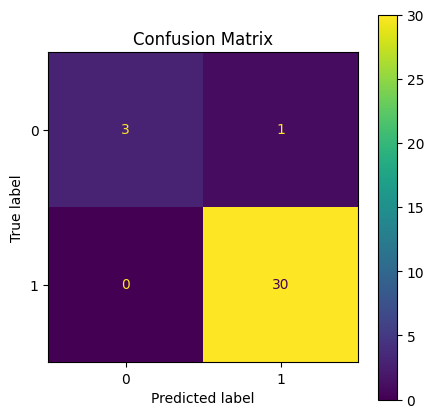

In [9]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

positive_label_name = CONFIG["default_positive_label"]
if positive_label_name not in label_encoder.classes_:
    positive_class_index = 1
else:
    positive_class_index = list(label_encoder.classes_).index(positive_label_name)

metrics = compute_metrics(
    y_true=y_test,
    y_pred=y_pred,
    y_prob_positive=y_prob[:, positive_class_index],
)

print("Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

plot_confusion(y_test, y_pred, labels=list(range(len(label_encoder.classes_))))


## 9) Optional Cross Validation

يفضل تشغيلها لمراجعة الثبات بدل الاعتماد على split واحدة فقط.


In [10]:
if CONFIG["run_cross_validation"]:
    X_all_scaled = scaler.fit_transform(X)
    cv = StratifiedKFold(
        n_splits=CONFIG["cv_folds"],
        shuffle=True,
        random_state=CONFIG["random_state"],
    )
    cv_scores = cross_val_score(
        MLPClassifier(
            hidden_layer_sizes=CONFIG["mlp_hidden_layers"],
            max_iter=CONFIG["mlp_max_iter"],
            random_state=CONFIG["random_state"],
        ),
        X_all_scaled,
        y,
        cv=cv,
        scoring="f1_macro",
    )
    print("Cross-validation F1 macro scores:", cv_scores)
    print("CV mean:", cv_scores.mean())
    print("CV std:", cv_scores.std())
else:
    print("Cross validation is disabled.")


Cross-validation F1 macro scores: [1.         1.         1.         0.88275862 0.8172043 ]
CV mean: 0.9399925843529848
CV std: 0.076361454811711


## 10) Save Artifacts

احفظ دائمًا:
- model
- scaler
- label_encoder
- feature_columns
- config

لأن الـ API لاحقًا ستحتاج نفس هذا الترتيب بالضبط.


In [11]:
model_path = os.path.join(CONFIG["artifacts_dir"], "model.pkl")
scaler_path = os.path.join(CONFIG["artifacts_dir"], "scaler.pkl")
label_encoder_path = os.path.join(CONFIG["artifacts_dir"], "label_encoder.pkl")
feature_columns_path = os.path.join(CONFIG["artifacts_dir"], "feature_columns.json")
config_path = os.path.join(CONFIG["artifacts_dir"], "config.json")

with open(model_path, "wb") as f:
    pickle.dump(model, f)

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

with open(label_encoder_path, "wb") as f:
    pickle.dump(label_encoder, f)

with open(feature_columns_path, "w", encoding="utf-8") as f:
    json.dump(FEATURE_COLUMNS, f, ensure_ascii=False, indent=2)

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, ensure_ascii=False, indent=2)

print("Saved:")
print("-", model_path)
print("-", scaler_path)
print("-", label_encoder_path)
print("-", feature_columns_path)
print("-", config_path)


Saved:
- ./covid_cough_project/artifacts\model.pkl
- ./covid_cough_project/artifacts\scaler.pkl
- ./covid_cough_project/artifacts\label_encoder.pkl
- ./covid_cough_project/artifacts\feature_columns.json
- ./covid_cough_project/artifacts\config.json


## 11) Inference on One WAV File

الخرج النهائي مصمم كـ **decision-support output**:
- `support_label`
- `risk_score`
- `class_probabilities`
- `clinical_use`
- `disclaimer`


In [12]:
def load_artifacts(artifacts_dir):
    with open(os.path.join(artifacts_dir, "model.pkl"), "rb") as f:
        model = pickle.load(f)

    with open(os.path.join(artifacts_dir, "scaler.pkl"), "rb") as f:
        scaler = pickle.load(f)

    with open(os.path.join(artifacts_dir, "label_encoder.pkl"), "rb") as f:
        label_encoder = pickle.load(f)

    with open(os.path.join(artifacts_dir, "feature_columns.json"), "r", encoding="utf-8") as f:
        feature_columns = json.load(f)

    with open(os.path.join(artifacts_dir, "config.json"), "r", encoding="utf-8") as f:
        saved_config = json.load(f)

    return model, scaler, label_encoder, feature_columns, saved_config


def predict_physician_support_from_wav(wav_path, artifacts_dir=None):
    if artifacts_dir is None:
        artifacts_dir = CONFIG["artifacts_dir"]

    model, scaler, label_encoder, feature_columns, saved_config = load_artifacts(artifacts_dir)

    feats = extract_features(
        wav_path,
        sample_rate=saved_config["sample_rate"],
        duration_sec=saved_config["duration_sec"],
    )

    row = pd.DataFrame([feats])
    row = row.reindex(columns=feature_columns, fill_value=0.0)

    x_scaled = scaler.transform(row)
    pred_idx = model.predict(x_scaled)[0]
    probas = model.predict_proba(x_scaled)[0]

    class_names = list(label_encoder.classes_)
    prob_dict = {cls: float(p) for cls, p in zip(class_names, probas)}

    positive_label = saved_config["default_positive_label"]
    risk_score = float(prob_dict.get(positive_label, max(probas)))

    if positive_label in prob_dict and prob_dict[positive_label] >= 0.5:
        support_label = "higher_covid_likelihood"
    else:
        support_label = "lower_covid_likelihood"

    return {
        "file_name": os.path.basename(wav_path),
        "predicted_class": class_names[pred_idx],
        "support_label": support_label,
        "risk_score": risk_score,
        "class_probabilities": prob_dict,
        "clinical_use": saved_config["clinical_use_text"],
        "disclaimer": saved_config["disclaimer_text"],
    }


In [14]:
# عدّل الملف هنا للتجربة بعد التدريب
TEST_WAV_PATH = r"D:\gradution project\dataaa\trial_covid\_0WKVY0n8aE_ 150.000_ 160.000.wav"
# مثال:
# TEST_WAV_PATH = r"D:\gradution project\dataaa\trial_covid\cov1.wav"

if TEST_WAV_PATH:
    result = predict_physician_support_from_wav(TEST_WAV_PATH)
    print(json.dumps(result, indent=2, ensure_ascii=False))
else:
    print("ضع مسار ملف wav في TEST_WAV_PATH لتجربة inference.")


{
  "file_name": "_0WKVY0n8aE_ 150.000_ 160.000.wav",
  "predicted_class": "not_covid",
  "support_label": "lower_covid_likelihood",
  "risk_score": 5.097838986944936e-06,
  "class_probabilities": {
    "covid": 5.097838986944936e-06,
    "not_covid": 0.999994902161013
  },
  "clinical_use": "physician_decision_support",
  "disclaimer": "This result is for clinical decision support only and must not be used as a standalone diagnosis."
}


## 12) Notes for API

عند تحويل المشروع إلى API لاحقًا، الجزء الذي ستحتاجه فعليًا هو:
1. `extract_features`
2. `load_artifacts`
3. `predict_physician_support_from_wav`

يعني الـ API ستستقبل ملف `.wav`، تحفظه مؤقتًا، ثم تستدعي نفس دالة الـ inference وترجع JSON.


## 13) Clinical Positioning

صياغة مناسبة للتقرير أو البرزنتيشن:

> This system is intended as a physician decision-support / screening prototype based on cough audio analysis.  
> It must not be used as a standalone diagnostic system.

الأفضل أيضًا عند العرض أن تذكر:
- النتائج تعتمد على جودة الداتا
- لا يجوز استخدامها كبديل عن PCR أو التقييم السريري
- القرار النهائي للطبيب
